In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


In [8]:
import pandas as pd
import os

#Agora, vou abrir o arquivo que baixei do kaggle com o pandas.
df = pd.read_csv(os.path.join(path, 'StudentsPerformance.csv'))

#Vendo as primeiras linhas da tabela:
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [9]:
#Fazendo o checkup dos dados:
#Para verificar os nomes de todas as colunas, usa-se:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
#Fazendo o checkup dos dados:
#Quero ver a média, o valor máximo e o valor mínimo de cada prova:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
#Comparando grupos: Quero comparar as médias de cada matéria, de quem fez o cursinho (test preparation course) e de quem não fez nada (none):
# 1. Agrupamos pela coluna do curso preparatório; Usa-se a função .groupby()
# 2. Selecionamos as colunas de notas que queremos calcular
# 3. Pedimos a média (.mean())

analise_curso = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()
print(analise_curso)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


In [12]:
#Agora, vou fazer gráficos:
#Usarei o seaborn para ficar esteticamente bonito.
import seaborn as sns
import matplotlib.pyplot as plt

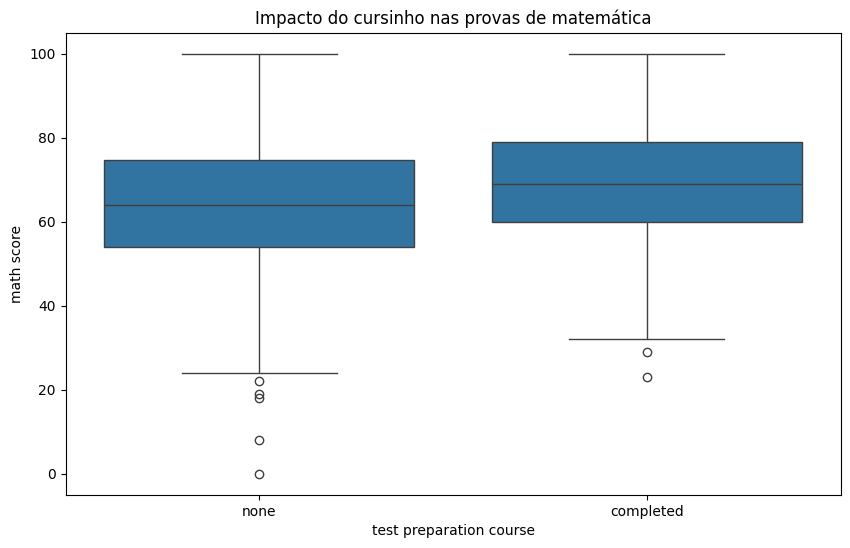

In [15]:
#Fazendo o gráfico:
plt.figure(figsize=(10,6))
sns.boxplot(x='test preparation course',y='math score', data=df) #O data=df indica ao computador que os dados vem de df.
plt.title('Impacto do cursinho nas provas de matemática')
plt.show()

In [22]:
#Obtendo a nota total (somando as 3 notas):
#Vou criar uma coluna nova na tabela que já tenho:
df['nota total'] = df['math score'] + df['reading score'] + df['writing score']

#Agora, vou obter a média simples das notas totais:
df['media simples'] = df['nota total'] / 3
print(df['nota total'].head(), df['media simples'].head())


0    218
1    247
2    278
3    148
4    229
Name: nota total, dtype: int64 0    72.666667
1    82.333333
2    92.666667
3    49.333333
4    76.333333
Name: media simples, dtype: float64


In [23]:
#Agora, vou fazer uma classificação, para ver quem foi aprovado (média acima de 70 pontos) e quem foi reprovado:
#Vou criar uma coluna de status:
#Vou usar a função .apply com a regra lambda. O código fica com a leitura: "Status depende da coluna de médias, mas com tais regras"
df['status'] = df['media simples'].apply(lambda x: 'Aprovado' if x >= 70 else 'Reprovado')

#Para ver quantos alunos passaram, preciso pedir para ele mostrar a tabela, mas mostrar a quantidade de alunos:
print(df['status'].value_counts())

status
Reprovado    541
Aprovado     459
Name: count, dtype: int64


/tmp/ipykernel_4203/2853516654.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'status', data=df, palette='viridis')


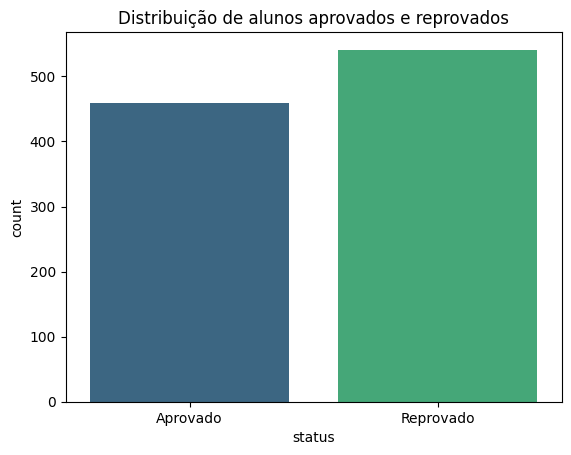

In [24]:
sns.countplot(x = 'status', data=df, palette='viridis')
plt.title('Distribuição de alunos aprovados e reprovados')
plt.show()

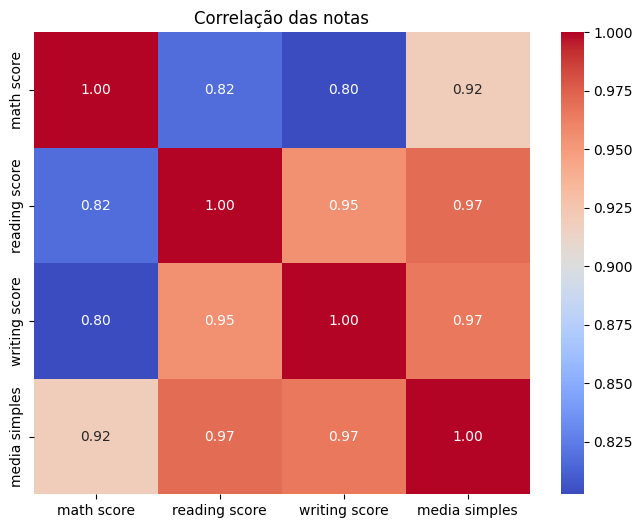

In [27]:
#Quero ver como uma nota influencia a outra:
#Vou criar uma tabela nova, só com notas:
tabela_de_notas = df[['math score', 'reading score', 'writing score', 'media simples']]

#Obtendo a correlação: A correlação vai de -1 a 1, sendo 1=diretamente roporcionais, -1=inversamente proporcionais.
correlacao = tabela_de_notas.corr()

#Desenhando um mapa de calor:
plt.figure(figsize=(8,6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f") #diz que precisa colocar a tabela de uma única coluna do gráfico, annot=True quer dizer que os números ficam dentro dos quadrados,
#cmap='coolwarm' representa a paleta de cores, e fmt='.2f' significa que os números são formatados em apenas 2 casas decimais.
plt.title('Correlação das notas')
plt.show()

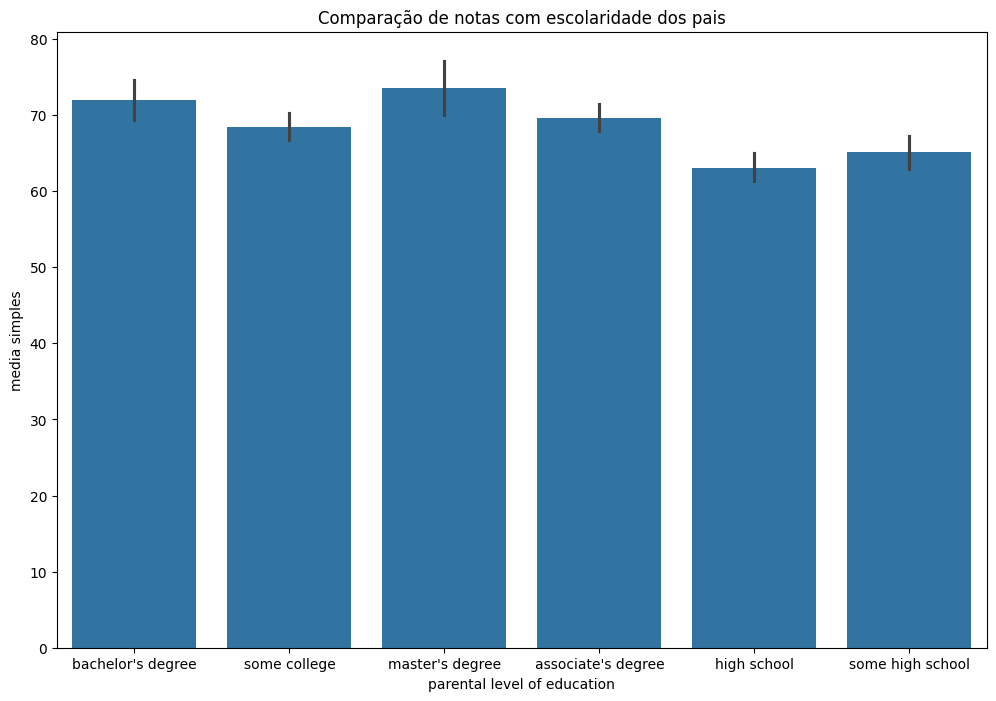

In [30]:
#Comparação de notas com escolaridade dos pais:
plt.figure(figsize=(12,8))
sns.barplot(x='parental level of education', y='media simples', data=df)
plt.title('Comparação de notas com escolaridade dos pais')
plt.show()